In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import pickle

In [ ]:
df = pd.read_csv('../../data/clean/heart_disease_clean.csv')

In [3]:
df

,Unnamed: 0,sex,age,cp,thalach,slope,exang,ca,thal,oldpeak,target
0,0,1,52,0,168,2,0,2,3,1.0,0
1,1,1,53,0,155,0,1,0,3,3.1,0
2,2,1,70,0,125,0,1,0,3,2.6,0
3,3,1,61,0,161,2,0,1,3,0.0,0
4,4,0,62,0,106,1,0,3,2,1.9,0
...,...,...,...,...,...,...,...,...,...,...,...
278,723,0,68,2,115,1,0,0,2,1.5,1
279,733,0,44,2,175,1,0,0,2,0.6,1
280,739,1,52,0,161,2,1,1,3,0.0,0
281,843,1,59,3,125,2,0,0,2,0.0,0


In [4]:
df = df.drop('Unnamed: 0', axis=1)

In [5]:
X = df.drop('target', axis=1)
y = df['target']

In [6]:
X.head()

,sex,age,cp,thalach,slope,exang,ca,thal,oldpeak
0,1,52,0,168,2,0,2,3,1.0
1,1,53,0,155,0,1,0,3,3.1
2,1,70,0,125,0,1,0,3,2.6
3,1,61,0,161,2,0,1,3,0.0
4,0,62,0,106,1,0,3,2,1.9


In [7]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(226, 9)
(57, 9)
(226,)
(57,)


In [10]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("The test accuracy score of Logistric Regression Classifier is ", accuracy_score(y_test, y_pred))

The test accuracy score of Logistric Regression Classifier is  0.8245614035087719


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81        26
           1       0.84      0.84      0.84        31

    accuracy                           0.82        57
   macro avg       0.82      0.82      0.82        57
weighted avg       0.82      0.82      0.82        57



In [12]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("The test accuracy score of Decision Tree Classifier is ", accuracy_score(y_test, y_pred))

The test accuracy score of Decision Tree Classifier is  0.7368421052631579


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.77      0.73        26
           1       0.79      0.71      0.75        31

    accuracy                           0.74        57
   macro avg       0.74      0.74      0.74        57
weighted avg       0.74      0.74      0.74        57



In [14]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("The test accuracy score of Random Forest Classifier is ", accuracy_score(y_test, y_pred))

The test accuracy score of Random Forest Classifier is  0.8245614035087719


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.77      0.80        26
           1       0.82      0.87      0.84        31

    accuracy                           0.82        57
   macro avg       0.83      0.82      0.82        57
weighted avg       0.83      0.82      0.82        57



In [16]:
clf = MLPClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("The test accuracy score of MLP Classifier is ", accuracy_score(y_test, y_pred))

The test accuracy score of MLP Classifier is  0.8070175438596491


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.88      0.81        26
           1       0.88      0.74      0.81        31

    accuracy                           0.81        57
   macro avg       0.81      0.81      0.81        57
weighted avg       0.82      0.81      0.81        57



In [18]:
clf = LogisticRegression()

param_grid = {
    'max_iter': [100, 200, 300, 1000],
    'C': [0.1, 0.2, 0.3],
    'solver' : ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
}

gs1 = GridSearchCV(
        estimator= clf,
        param_grid = param_grid,
        cv=3,
        n_jobs=-1,
        scoring='roc_auc'
    )

fit_clf_lg = gs1.fit(X_train, y_train)

print("Best hyper parameter: ", fit_clf_lg.best_params_)
print("Best Score : ", fit_clf_lg.best_score_)

Best hyper parameter:  {'C': 0.3, 'max_iter': 100, 'solver': 'liblinear'}
Best Score :  0.9214123516449098


In [19]:
y_pred = fit_clf_lg.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82        26
           1       0.84      0.87      0.86        31

    accuracy                           0.84        57
   macro avg       0.84      0.84      0.84        57
weighted avg       0.84      0.84      0.84        57



In [20]:
clf = RandomForestClassifier(random_state=42)

param_grid = {'n_estimators': [100, 200, 300],
               'max_depth': [None, 10, 20, 30],
               'criterion': ['gini', 'entropy', 'log_loss']}

gs1 = GridSearchCV(
        estimator=clf,
        param_grid = param_grid,
        cv=3,
        n_jobs=-1,
        scoring='roc_auc'
    )

fit_clf_rf = gs1.fit(X_train, y_train)

print(fit_clf_rf.best_params_)
print(fit_clf_rf.best_score_)

{'criterion': 'entropy', 'max_depth': None, 'n_estimators': 100}
0.9121670749577726


In [21]:
y_pred = fit_clf_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.73      0.78        26
           1       0.79      0.87      0.83        31

    accuracy                           0.81        57
   macro avg       0.81      0.80      0.80        57
weighted avg       0.81      0.81      0.81        57



In [22]:
clf = DecisionTreeClassifier(random_state=42)

param_grid = {'min_samples_leaf': [1, 2, 5, 10, 20],
               'max_depth': [None, 10, 20, 30],
               'criterion': ['gini', 'entropy', 'log_loss']}

gs1 = GridSearchCV(
        estimator=clf,
        param_grid = param_grid,
        cv=3,
        n_jobs=-1,
        scoring='roc_auc'
    )

fit_clf_dt = gs1.fit(X_train, y_train)

print(fit_clf_dt.best_params_)
print(fit_clf_dt.best_score_)

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 10}
0.8898341107643434


In [23]:
y_pred = fit_clf_dt.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.73      0.78        26
           1       0.79      0.87      0.83        31

    accuracy                           0.81        57
   macro avg       0.81      0.80      0.80        57
weighted avg       0.81      0.81      0.81        57



In [24]:
clf = MLPClassifier(random_state=42)

param_grid = {'hidden_layer_sizes': [(50,50,50), (50,100,100), (100,)],
               'activation': ['tanh', 'relu'],
               'solver': ['sgd', 'adam']}

gs1 = GridSearchCV(
        estimator=clf,
        param_grid = param_grid,
        cv=3,
        n_jobs=-1,
        scoring='roc_auc'
    )

fit_clf_mlp = gs1.fit(X_train, y_train)

print(fit_clf_mlp.best_params_)
print(fit_clf_mlp.best_score_)

{'activation': 'tanh', 'hidden_layer_sizes': (100,), 'solver': 'adam'}
0.9201874783270133


In [25]:
y_pred = fit_clf_mlp.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82        26
           1       0.84      0.87      0.86        31

    accuracy                           0.84        57
   macro avg       0.84      0.84      0.84        57
weighted avg       0.84      0.84      0.84        57



In [26]:
y_pred_logreg = fit_clf_lg.predict_proba(X_test)[:, 1]
y_pred_rf = fit_clf_rf.predict_proba(X_test)[:, 1]
y_pred_dt= fit_clf_dt.predict_proba(X_test)[:, 1]
y_pred_mlp= fit_clf_mlp.predict_proba(X_test)[:, 1]

auc_logreg = roc_auc_score(y_test, y_pred_logreg)
auc_rf = roc_auc_score(y_test, y_pred_rf)
auc_dt = roc_auc_score(y_test, y_pred_dt)
auc_mlp = roc_auc_score(y_test, y_pred_mlp)

print(f"AUC-ROC for Logistic Regression: {auc_logreg}")
print(f"AUC-ROC for Random Forest: {auc_rf}")
print(f"AUC-ROC for Decision Tree: {auc_dt}")
print(f"AUC-ROC for MLP: {auc_mlp}")

AUC-ROC for Logistic Regression: 0.8759305210918115
AUC-ROC for Random Forest: 0.903225806451613
AUC-ROC for Decision Tree: 0.847394540942928
AUC-ROC for MLP: 0.8970223325062036


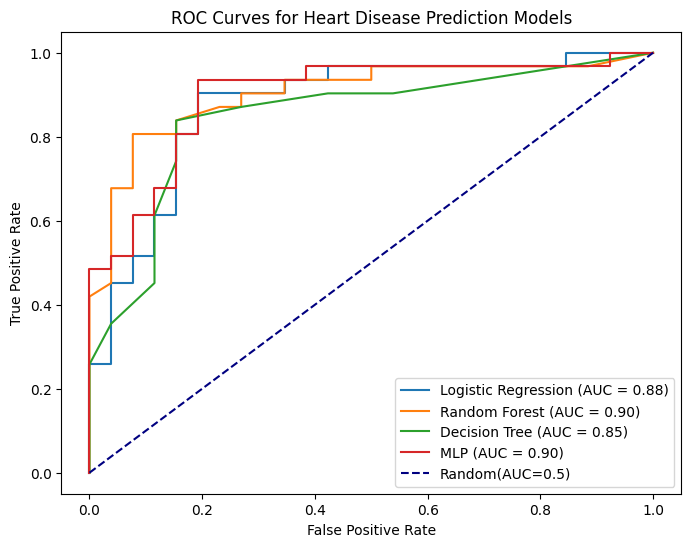

In [27]:
def plot_roc_curves(y_test, y_pred_logreg, y_pred_rf, y_pred_dt, y_pred_mlp):
    plt.figure(figsize=(8, 6))

    fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_logreg)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
    fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt)
    fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_mlp)

    plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.2f})')
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
    plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
    plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc_mlp:.2f})')

    plt.plot([0,1],[0,1], color='navy', linestyle='--', label='Random(AUC=0.5)')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Heart Disease Prediction Models')
    plt.legend()
    plt.show()

plot_roc_curves(y_test, y_pred_logreg, y_pred_rf, y_pred_dt, y_pred_mlp)

In [28]:
def find_rates_for_thresholds(y_test, y_pred, thresholds):
    fpr_list = []
    tpr_list = []
    for threshold in thresholds:
        y_pred_binary = (y_pred > threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()
        fpr = fp / (fp + tn)
        tpr = tp / (tp + fn)
        fpr_list.append(fpr)
        tpr_list.append(tpr)
    return fpr_list, tpr_list

thresholds = np.arange(0, 1.1, 0.1)

fpr_logreg, tpr_logreg = find_rates_for_thresholds(y_test, y_pred_logreg, thresholds)
fpr_rf, tpr_rf = find_rates_for_thresholds(y_test, y_pred_rf, thresholds)
fpr_dt, tpr_dt = find_rates_for_thresholds(y_test, y_pred_dt, thresholds)
fpr_mlp, tpr_mlp = find_rates_for_thresholds(y_test, y_pred_mlp, thresholds)

summary_df = pd.DataFrame({
    'Threshold': thresholds,
    'Logistic Regression FPR': fpr_logreg,
    'Logistic Regression TPR': tpr_logreg,
    'Random Forest FPR': fpr_rf,
    'Random Forest TPR': tpr_rf,
    'Decision Tree FPR': fpr_dt,
    'Decision Tree TPR': tpr_dt,
    'MLP FPR': fpr_mlp,
    'MLP TPR': tpr_mlp
})

print(summary_df)

    Threshold  Logistic Regression FPR  Logistic Regression TPR  \
0         0.0                 1.000000                 1.000000   
1         0.1                 0.500000                 0.967742   
2         0.2                 0.384615                 0.935484   
3         0.3                 0.307692                 0.903226   
4         0.4                 0.192308                 0.903226   
5         0.5                 0.192308                 0.870968   
6         0.6                 0.153846                 0.774194   
7         0.7                 0.115385                 0.548387   
8         0.8                 0.076923                 0.483871   
9         0.9                 0.000000                 0.193548   
10        1.0                 0.000000                 0.000000   

    Random Forest FPR  Random Forest TPR  Decision Tree FPR  \
0            0.884615           0.967742           0.538462   
1            0.615385           0.967742           0.423077   
2     

In [29]:
def find_best_threshold(y_test, y_pred):
    # based on Youden's Index
    fpr, tpr, thresholds = roc_curve(y_test,y_pred)
    optimal_idx = np.argmax(tpr-fpr)
    return thresholds[optimal_idx]
best_threshold_logreg = find_best_threshold(y_test, y_pred_logreg)
best_threshold_rf = find_best_threshold(y_test, y_pred_rf)
best_threshold_dt = find_best_threshold(y_test, y_pred_dt)
best_threshold_mlp = find_best_threshold(y_test, y_pred_mlp)
print(f"Best threshold for Logistic Regression: {best_threshold_logreg}")
print(f"Best threshold for Random Forest: {best_threshold_rf}")
print(f"Best threshold for Decision Tree: {best_threshold_dt}")
print(f"Best threshold for MLP: {best_threshold_mlp}")

Best threshold for Logistic Regression: 0.4088907043420886
Best threshold for Random Forest: 0.68
Best threshold for Decision Tree: 0.6111111111111112
Best threshold for MLP: 0.44364298125586976


In [30]:
pklname = "best_classifier.pkl"

with open(pklname, 'wb') as file:
    pickle.dump(fit_clf_rf, file)

from google.colab import files
files.download(pklname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>